In [290]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls
import matplotlib.pyplot as plt
import itertools
import torch
import torch.nn as nn
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

rng = np.random.default_rng(seed=None)

# Set a nice default style
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 12

# Preferably use a GPU instead of CPU
print(f"PyTorch version: {torch.__version__}")
# --- Auto-detect GPU (CUDA or Apple MPS) — falls back to CPU ---
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

PyTorch version: 2.12.0+cpu
Using device: cpu


In [291]:
def generate_mixture_spectra(
    df,
    wavelength_col="Wavelength",
    combination_sizes=(2, 3),
    n_mixtures_per_combination=25,
    random_state=42
):
    """
    df: DataFrame with one wavelength column and one column per pure spectrum.
        Example columns: ['Wavelength', 'Diatom_Ptricornutum', ...]
    wavelength_col: name of the wavelength column.
    combination_sizes: tuple with sizes of combinations (e.g. (1, 2, 3, 4)).
        - 1 means single-species "mixtures" (i.e. just that pure spectrum again).
    n_mixtures_per_combination: number of random weightings per given combination.
    random_state: seed for reproducibility.

    Returns:
        mixtures_df: DataFrame with:
            - the wavelength column
            - one column per pure spectrum (copied from df)
            - additional columns for artificial mixtures
        weights_df: DataFrame that stores the weights used for each mixture column
            (so you know the exact composition).
    """
    rng = np.random.default_rng(random_state)

    # All species columns
    spectrum_cols = [c for c in df.columns if c != wavelength_col]

    # To store composition (weights) for each mixture column
    weights_records = []

    new_mixtures_dict = {}

    for k in combination_sizes:
        # All k-element combinations of the spectrum columns
        for comb in itertools.combinations(spectrum_cols, k):
            comb_name_base = "_".join(comb)

            for m in range(n_mixtures_per_combination):
                # Random non-negative weights that sum to 1
                weights = rng.dirichlet(np.ones(k))

                # Global concentration scaling for more realistic spectra (will be much more diluted than basis spectra's samples)
                total_scale = rng.uniform(0.001, 0.01)
                weights *= total_scale
                
                # Linear combination: mix = sum_i w_i * spectrum_i
                mix_spectrum = np.zeros(len(df))
                for col, w in zip(comb, weights):
                    mix_spectrum += w * df[col].values

                # Unique column name for this mixture
                mix_col_name = f"mix{k}_{comb_name_base}_{m}"

                new_mixtures_dict[mix_col_name] = mix_spectrum

                # Store the weights and which species were used
                record = {"mixture_name": mix_col_name}
                for col, w in zip(comb, weights):
                    record[col] = w
                weights_records.append(record)

    new_mixtures_df = pd.DataFrame(new_mixtures_dict)
    mixtures_df = pd.concat([df, new_mixtures_df], axis=1)

    weights_df = pd.DataFrame(weights_records).fillna(0.0)

    return mixtures_df, weights_df

In [292]:
df = pd.read_excel('Spectral_library_clean.xlsx')
df.ffill(axis=0, inplace=True)
df.bfill(axis=0, inplace=True)  # handles leading NaNs

# if there is a NaN, interpolate data linearly

wavelength = df['Wavelength']

In [293]:
class Sparsemax(nn.Module):
    def forward(self, z):
        dim = 1
        z_sorted, _ = torch.sort(z, dim=dim, descending=True)
        
        css = torch.cumsum(z_sorted, dim=dim)

        z_index = torch.arange(1, z.shape[dim] + 1, device=z.device).float()
        bound = 1 + z_index * z_sorted > css
        k = bound.sum(dim=dim, keepdim=True).float()
        
        tau = (torch.gather(css, dim, (k - 1).long()) - 1) / k
        
        return torch.clamp(z - tau, min=0.0)

def training_loop(
    nr_epochs,
    epochs_no_improvement,
    X_train_,
    y_train_,
    X_val_,
    y_val_,
    wavelength,
    target_scale=1000.0
):  
    N_species = y_train_.shape[1]

    X_train_ = X_train_.reshape(-1, len(wavelength)).float()
    X_val_   = X_val_.reshape(-1, len(wavelength)).float()

    # scale targets for easier training
    y_train_ = y_train_.reshape(-1, N_species).float() * target_scale
    y_val_   = y_val_.reshape(-1, N_species).float() * target_scale

    model = nn.Sequential(
        nn.Linear(len(wavelength), 128),
        nn.ReLU(),
        nn.Linear(128, N_species),
        nn.Softplus()
    )

    # now outputs are around 1–10, not 0.001–0.01
    final_linear = model[2]
    nn.init.constant_(final_linear.bias, 0.0)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=20, factor=0.5, min_lr=1e-6
    )

    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []
    train_maes = []
    val_maes = []
    epochs_list = []

    best_val_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(nr_epochs):
        model.train()
        optimizer.zero_grad()

        pred = model(X_train_)
        loss = criterion(pred, y_train_)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            train_mae_per_species = torch.mean(
                torch.abs(pred - y_train_), dim=0
            ).tolist()

        model.eval()
        with torch.no_grad():
            pred_val = model(X_val_)
            loss_val = criterion(pred_val, y_val_)

            val_mae_per_species = torch.mean(
                torch.abs(pred_val - y_val_), dim=0
            ).tolist()

        train_losses.append(loss.item())
        val_losses.append(loss_val.item())
        train_maes.append(train_mae_per_species)
        val_maes.append(val_mae_per_species)
        epochs_list.append(epoch)

        if loss_val.item() < best_val_loss:
            best_val_loss = loss_val.item()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement > epochs_no_improvement:
            print(f"Early stopping triggered at epoch {epoch}")
            break

        scheduler.step(loss_val.item())

    return train_losses, val_losses, train_maes, val_maes, epochs_list, model

In [294]:
mixtures_df, weights_df = generate_mixture_spectra(df, combination_sizes=(2, 3, 4, 5, 6, 7, 8, 9), n_mixtures_per_combination=20)

mixture_columns = weights_df['mixture_name'].tolist()
X_numpy = mixtures_df[mixture_columns].T.values 

y_df = weights_df.drop(columns=['mixture_name'])
y_numpy = y_df.values

X_train, X_val, y_train, y_val = train_test_split(X_numpy, y_numpy, test_size=0.2, random_state=42)

X_train_ = torch.tensor(X_train, dtype=torch.float32)
X_val_ = torch.tensor(X_val, dtype=torch.float32)
y_train_ = torch.tensor(y_train, dtype=torch.float32)
y_val_ = torch.tensor(y_val, dtype=torch.float32)

absolute_noise = 0.0
relative_noise = 0.002

# TRAIN
train_noise = torch.randn_like(X_train_)

train_signal_scale = torch.max(
    torch.abs(X_train_),
    dim=1,
    keepdim=True
).values

X_train_ = (
    X_train_
    + absolute_noise * train_noise
    + relative_noise * train_signal_scale * train_noise
)

# VALIDATION
val_noise = torch.randn_like(X_val_)

val_signal_scale = torch.max(
    torch.abs(X_val_),
    dim=1,
    keepdim=True
).values

X_val_ = (
    X_val_
    + absolute_noise * val_noise
    + relative_noise * val_signal_scale * val_noise
)

# Normalize X
mean = X_train_.mean(dim=0, keepdim=True)
std = X_train_.std(dim=0, keepdim=True) + 1e-8
X_train_ = (X_train_ - mean) / std
X_val_ = (X_val_ - mean) / std

In [295]:
train_losses, val_losses, train_maes, val_maes, epochs_list, trained_model = training_loop(10000, 20, X_train_, y_train_, X_val_, y_val_, wavelength)


Early stopping triggered at epoch 5948


In [296]:
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

trained_model.eval()

with torch.no_grad():
    pred_val_scaled = trained_model(X_val_)
    pred_val = pred_val_scaled / 1000.0
    
    # Calculate absolute error for every prediction
    abs_errors = torch.abs(pred_val - y_val)

# Calculate 
per_mixture_mae = torch.mean(abs_errors, dim=1).cpu().numpy()
per_mixture_std = torch.std(abs_errors, dim=1).cpu().numpy()
overall_mean_mae = np.mean(per_mixture_mae)

per_species_mae = torch.mean(abs_errors, dim=0).cpu().numpy()
per_species_std = torch.std(abs_errors, dim=0).cpu().numpy()

species_names = [
    "Diatom_Ptricornutum", "Diatom_Csimplex", 
    "Chlamydomonas_Cprisculi", "Chlamydomonas_Creindhardtii", 
    "Dinoflagellate_Symbiodiniumsp", "Dinoflagellate_Smicroadriaticum",
    "Dinoflagellate_Dtrenchii", "Dinoflagellate_Cgoreaui",
    "Cyanobacteria_Synechosystis"
]

In [297]:
print(pred_val.shape)

torch.Size([2008, 9])


(5949, 9)


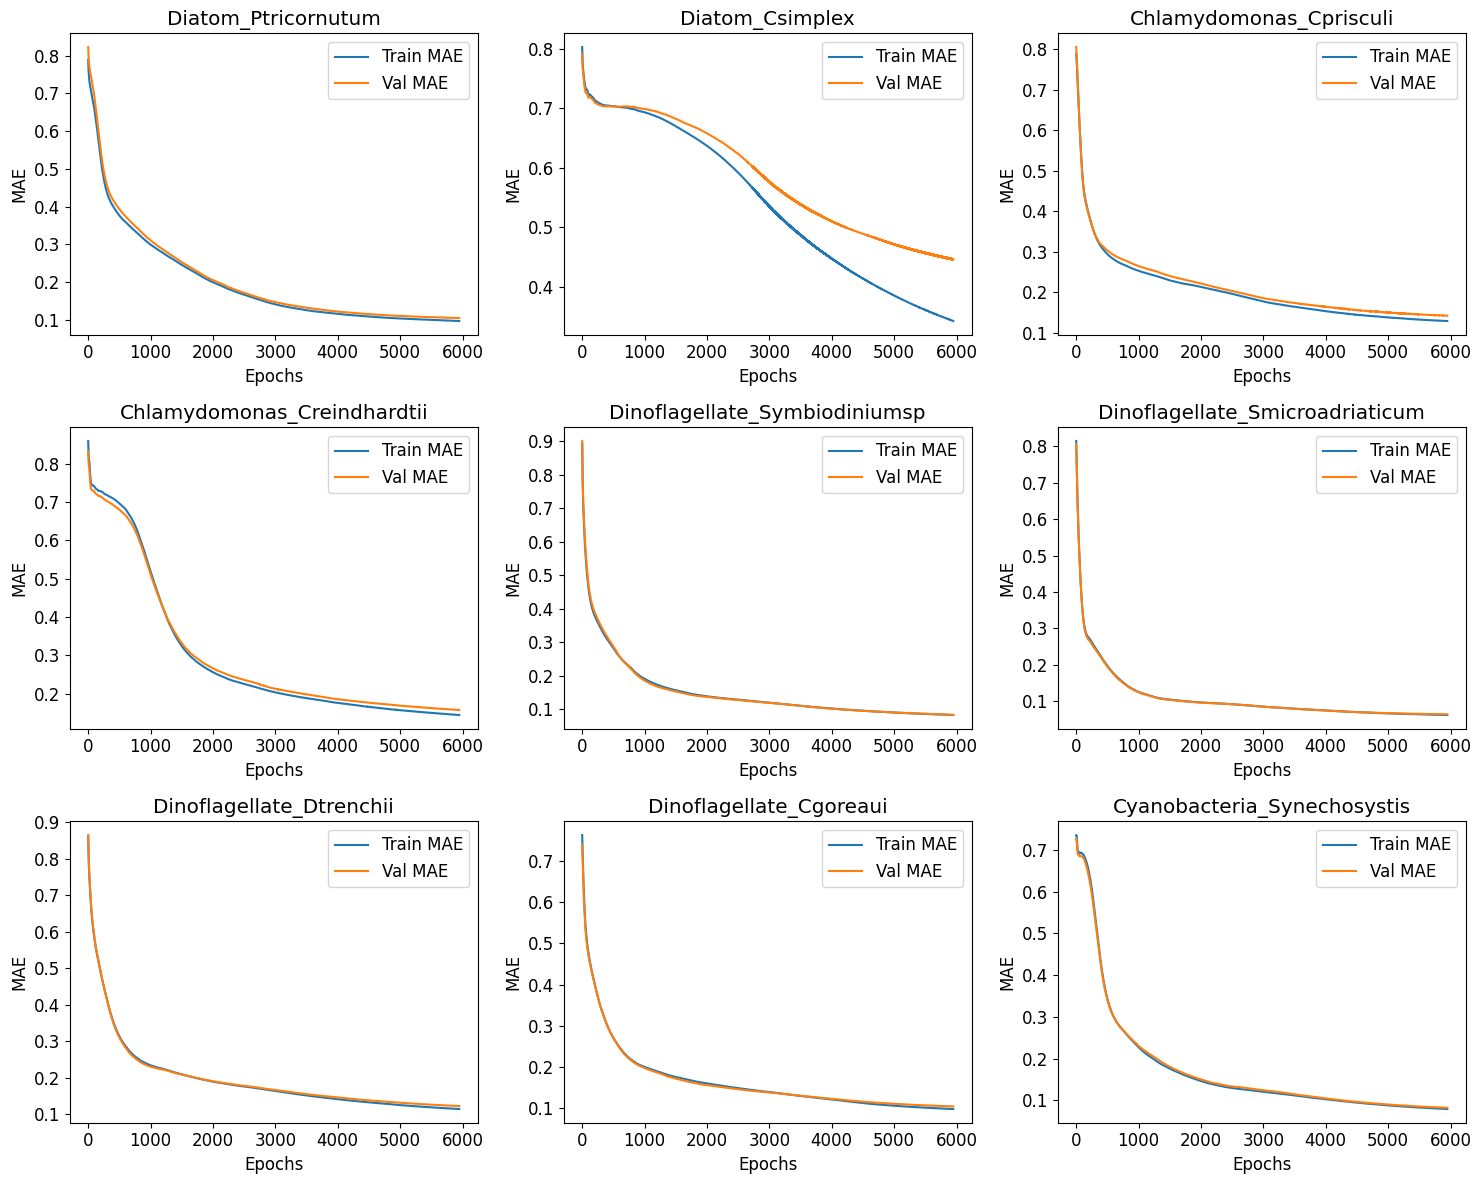

In [298]:
train_maes_np = np.array(train_maes)
val_maes_np = np.array(val_maes)

print(val_maes_np.shape)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i in range(9):
    axes[i].plot(train_maes_np[:, i], label='Train MAE')
    axes[i].plot(val_maes_np[:, i], label='Val MAE')
    
    axes[i].set_title(f'{species_names[i]}')
    axes[i].set_xlabel('Epochs')
    axes[i].set_ylabel('MAE')
    axes[i].legend()

plt.tight_layout()
plt.show()

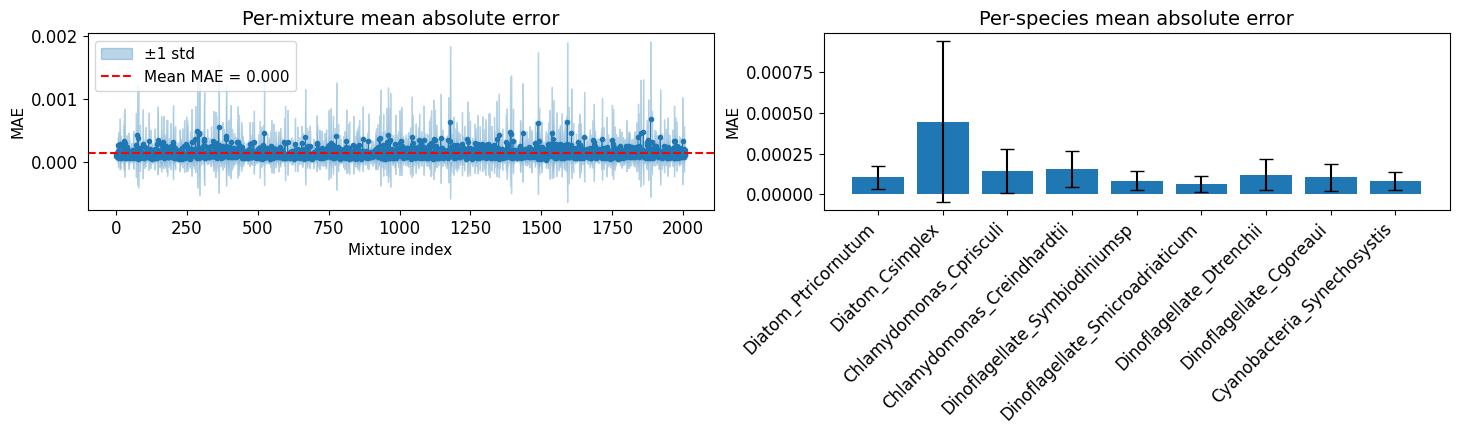

In [299]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

ax1 = axes[0]
mixture_indices = np.arange(len(per_mixture_mae))

ax1.plot(mixture_indices, per_mixture_mae, marker='.', linestyle='-', lw=0.5, markersize=6, color='tab:blue')

ax1.fill_between(mixture_indices, 
                 per_mixture_mae - per_mixture_std, 
                 per_mixture_mae + per_mixture_std, 
                 alpha=0.3, color='tab:blue', label='±1 std')

ax1.axhline(overall_mean_mae, color='red', linestyle='--', lw=1.5, label=f'Mean MAE = {overall_mean_mae:.3f}')

ax1.set_title("Per-mixture mean absolute error", fontsize=14)
ax1.set_xlabel("Mixture index", fontsize=11)
ax1.set_ylabel("MAE", fontsize=11)
ax1.legend(loc='upper left', fontsize=11)

ax2 = axes[1]
x_pos = np.arange(len(species_names))

ax2.bar(x_pos, per_species_mae, yerr=per_species_std, capsize=5, color='tab:blue')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(species_names, rotation=45, ha="right")

ax2.set_title("Per-species mean absolute error", fontsize=14)
ax2.set_ylabel("MAE", fontsize=11)

plt.tight_layout()
plt.show()

In [300]:
print(mixtures_df.shape)
print(mixtures_df)

(451, 10050)
     Wavelength  Diatom_Ptricornutum  Diatom_Csimplex  \
0           800              0.00908         -0.00356   
1           799              0.00908         -0.00356   
2           798              0.00908         -0.00356   
3           797              0.00908         -0.00356   
4           796              0.00908         -0.00356   
..          ...                  ...              ...   
446         354              0.15854          0.03724   
447         353              0.16035          0.03678   
448         352              0.15539          0.03662   
449         351              0.15917          0.03660   
450         350              0.15971          0.03701   

     Chlamydomonas_Cpriscuii  Chlamydomonas_Creindhardtii  \
0                   -0.01940                     -0.00275   
1                   -0.01940                     -0.00275   
2                   -0.01940                     -0.00275   
3                   -0.01940                     -0.00275 

In [301]:
# Adapt some variables for code below
weights = weights_df.copy()
weights = weights_df.drop(['mixture_name'], axis=1).to_numpy()
print(weights.shape)

X_all_tensor = torch.tensor(X_numpy, dtype=torch.float32)
X_all_tensor = (X_all_tensor - mean) / std

trained_model.eval()
with torch.no_grad():
    pred_all_scaled = trained_model(X_all_tensor)
    pred_all = pred_all_scaled / 1000.0

estimated_concentrations = pd.DataFrame(
    pred_all.cpu().numpy(),
    columns=species_names,
).to_numpy()

print(estimated_concentrations.shape)

(10040, 9)
(10040, 9)


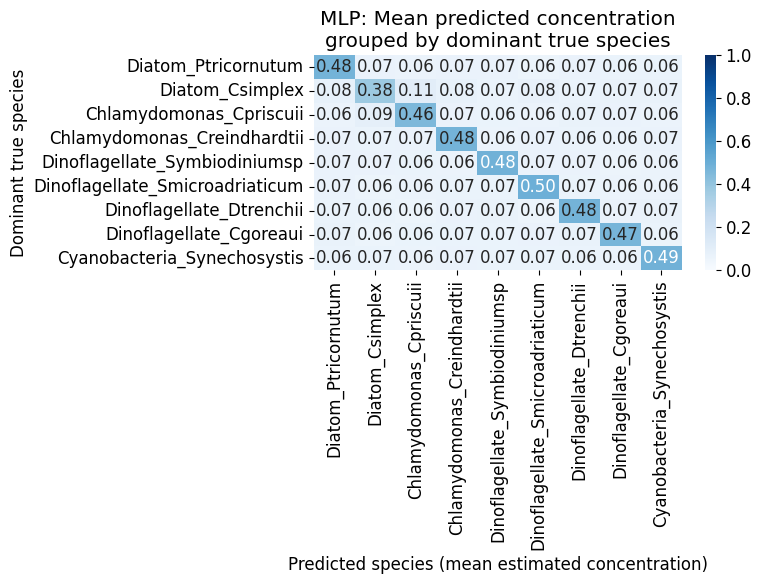

In [302]:
# ground_truth shape: (4600, 9), estimated_concentrations shape: (4600, 9)
# Identify dominant species per mixture (highest true weight)
dominant_species = np.argmax(weights, axis=1)  # (4600,)

n_species = weights.shape[1]
heatmap = np.zeros((n_species, n_species))
species_names = df.columns[1:].tolist()

for i in range(n_species):
    # Select all mixtures where species i is dominant
    mask = dominant_species == i
    if mask.sum() > 0:
        # Average predicted concentration of each species j in those mixtures
        heatmap[i, :] = estimated_concentrations[mask].mean(axis=0)

# Optional: normalize each row so values sum to 1
heatmap_norm = heatmap / heatmap.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=species_names,
    yticklabels=species_names,
    ax=ax,
    vmin=0, vmax=1
)
ax.set_xlabel("Predicted species (mean estimated concentration)")
ax.set_ylabel("Dominant true species")
ax.set_title("MLP: Mean predicted concentration\ngrouped by dominant true species")
plt.tight_layout()
plt.show()
# this does not show how the model performs. This plot picks dominant species. Dominant species can have weights of .31, so the spectra is still dominated by the other species! 
# That's why this does not show high diagonal values. To fix this, use a mask with a threshold for the weights -- only dominant species with weights > .6-.8 will show. 


Sample counts per species at different thresholds:
  thresh=0.4: [0 0 0 0 0 0 0 0 0] (total=0)
  thresh=0.5: [0 0 0 0 0 0 0 0 0] (total=0)
  thresh=0.6: [0 0 0 0 0 0 0 0 0] (total=0)
  thresh=0.7: [0 0 0 0 0 0 0 0 0] (total=0)
[[0.0044263  0.00430108 0.         0.         0.         0.
  0.         0.         0.        ]
 [0.0074722  0.0023084  0.         0.         0.         0.
  0.         0.         0.        ]
 [0.0006695  0.00148352 0.         0.         0.         0.
  0.         0.         0.        ]
 [0.00875186 0.00058902 0.         0.         0.         0.
  0.         0.         0.        ]
 [0.00407917 0.00091156 0.         0.         0.         0.
  0.         0.         0.        ]]


C:\Users\Nuri\AppData\Local\Temp\ipykernel_16752\243052479.py:26: RuntimeWarning: invalid value encountered in divide
  heatmap_norm = heatmap / heatmap.sum(axis=1, keepdims=True)


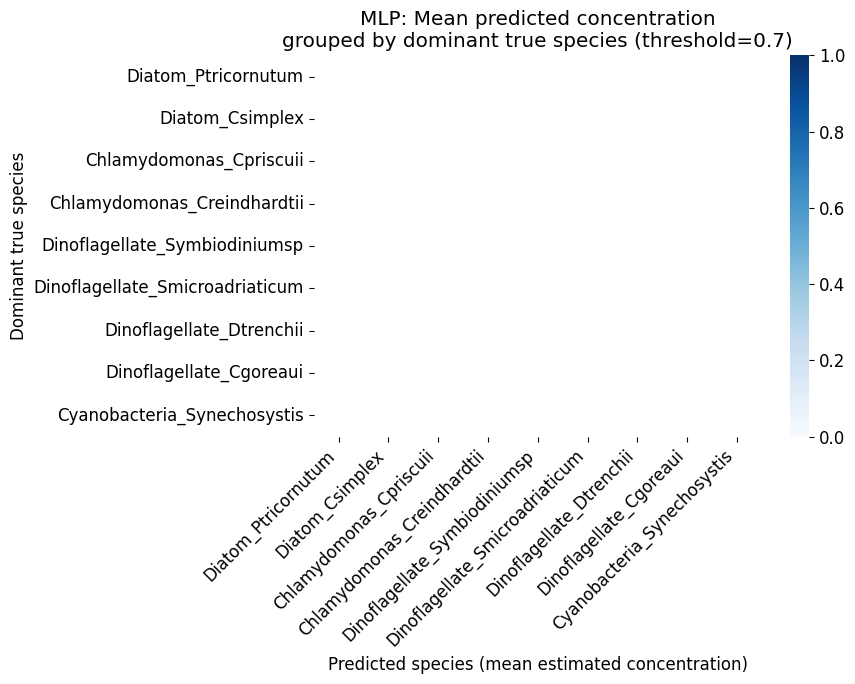

In [303]:
threshold = 0.7  # adjust as needed

# Print sample counts per species at each threshold
print("Sample counts per species at different thresholds:")
for thresh in [0.4, 0.5, 0.6, 0.7]:
    mask = weights.max(axis=1) > thresh
    counts = np.bincount(np.argmax(weights[mask], axis=1), minlength=9)
    print(f"  thresh={thresh}: {counts} (total={mask.sum()})")
print(weights[:5])
# Apply threshold: only keep mixtures where dominant species > threshold
mask_dominant = weights.max(axis=1) > threshold
gt_filtered   = weights[mask_dominant]
ec_filtered   = estimated_concentrations[mask_dominant]

dominant_species = np.argmax(gt_filtered, axis=1)

n_species = weights.shape[1]
heatmap = np.zeros((n_species, n_species))

for i in range(n_species):
    mask = dominant_species == i
    if mask.sum() > 0:
        heatmap[i, :] = ec_filtered[mask].mean(axis=0)

# Normalize rows to sum to 1
heatmap_norm = heatmap / heatmap.sum(axis=1, keepdims=True)

species_names = [
    "Diatom_Ptricornutum", "Diatom_Csimplex", "Chlamydomonas_Cpriscuii",
    "Chlamydomonas_Creindhardtii", "Dinoflagellate_Symbiodiniumsp",
    "Dinoflagellate_Smicroadriaticum", "Dinoflagellate_Dtrenchii",
    "Dinoflagellate_Cgoreaui", "Cyanobacteria_Synechosystis"
]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=species_names,
    yticklabels=species_names,
    ax=ax,
    vmin=0, vmax=1
)
ax.set_xlabel("Predicted species (mean estimated concentration)")
ax.set_ylabel("Dominant true species")
ax.set_title(f"MLP: Mean predicted concentration\ngrouped by dominant true species (threshold={threshold})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
# contuining from last comment, this works waaay better!

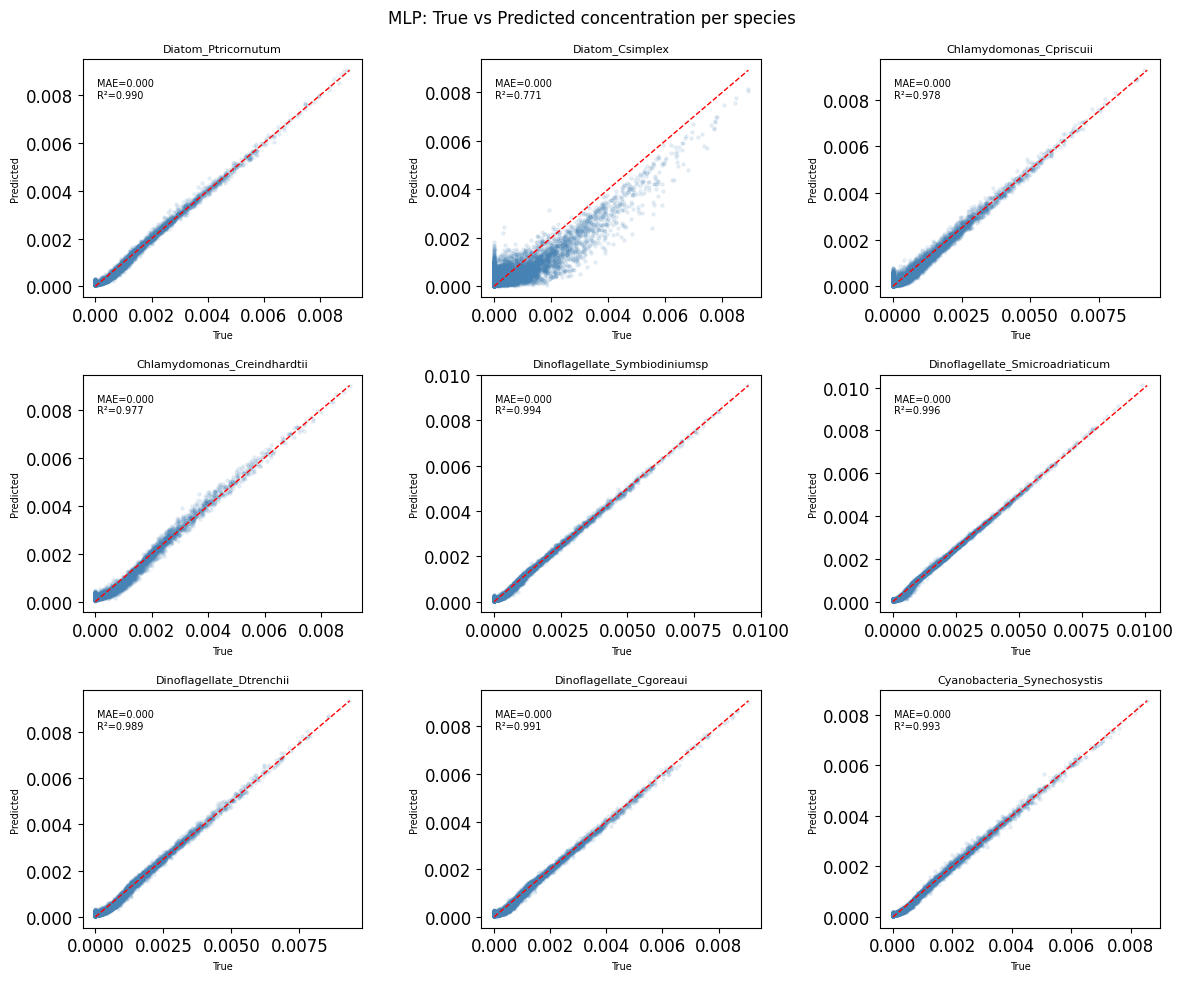

In [304]:
n_species = len(species_names)
ground_truth = weights
# --- Per-species metrics ---
r2_per_species  = [r2_score(ground_truth[:, i], estimated_concentrations[:, i]) for i in range(n_species)]

# --- Scatter plots: true vs predicted per species ---
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(species_names, axes)):
    ax.scatter(ground_truth[:, i], estimated_concentrations[:, i], alpha=0.1, s=5, color="steelblue")
    # Perfect prediction line
    lim = [0, max(ground_truth[:, i].max(), estimated_concentrations[:, i].max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel("True", fontsize=7)
    ax.set_ylabel("Predicted", fontsize=7)
    ax.text(0.05, 0.92, f"MAE={per_mixture_mae[i]:.3f}\nR²={r2_per_species[i]:.3f}",
            transform=ax.transAxes, fontsize=7, verticalalignment='top')

plt.suptitle("MLP: True vs Predicted concentration per species", fontsize=12)
plt.tight_layout()
plt.show()
# shows predicted concentration values on y-axis versus the true concentration on x-axis. If it is perfect, it should follow the red line (linear). 
# R^2 determines how well the linear fit is. For noise_level = 0, it is perfect!

In [305]:
# Get actual concentrations
def conc_from_weights(mixture_weights):
    
    """
    mixture_weights: weights for one mixture

    Returns: 1-D arrays with
        abs_Chla: absorbances of each strain at 662 nm 
        Chla_cell: Chlorophyll a per cell in kg
        c_Chla: Chla concentration
        cells_per_volume: cells of each strain per litre
    """
    epsilon_chla = 78.75e5* (893.509)**(-1)   # extinction coefficient of Chl a [l/(g*m)]
    l = 1e-2            # cuvette path length, assumed to be standard 1 cm

   # select Chl a region (from literature)
    mask = (wavelength >= 660) & (wavelength <= 700)
    peak_idx = df.loc[mask, species_names].idxmax(axis=0)

    peak_absorbance = pd.Series(index=species_names, dtype=float)
    peak_wavelength = pd.Series(index=species_names, dtype=float)

    for species in species_names:
        peak_idx = df.loc[mask, species].idxmax()

        peak_wavelength[species] = df.loc[peak_idx, "Wavelength"]
        peak_absorbance[species] = df.loc[peak_idx, species]

    abs_Chla = mixture_weights * peak_absorbance
    

    # Provide Chl a (for Chlamydomonas_Cpriscuii: Chl b, Chl a: Chl b ~ 1 here) per cell, 
    # in moles/cell (molecular weight Chla: 893.509 g/mol, Chl b: 907.49(893.509) more robust, against re-arrangement of the columns in this case
    # ideally, Chl a per cell per strain (environment-dependent) would be saved along with the non-mixed absorption spectra

    Chla_cell = pd.Series(
        {
            "Diatom_Ptricornutum": 0.3,
            "Diatom_Csimplex": 1.285,
            "Chlamydomonas_Cpriscuii": 2.17,
            "Chlamydomonas_Creindhardtii": 2.2,
            "Dinoflagellate_Symbiodiniumsp": 7,
            "Dinoflagellate_Smicroadriaticum": 16,
            "Dinoflagellate_Dtrenchii": 6,
            "Dinoflagellate_Cgoreaui": 7.25,
            "Cyanobacteria_Synechosystis": 0.008,
        },
        dtype=float,
    ) * 1e-12 # in g per cell

    # name match check
    missing_in_df = Chla_cell.index.difference(abs_Chla.index)
    missing_in_chla = abs_Chla.index.difference(Chla_cell.index)

    if len(missing_in_df) or len(missing_in_chla):
        raise ValueError(
            f"Name mismatch.\n"
            f"In Chla_cell but not df: {list(missing_in_df)}\n"
            f"In df but not Chla_cell: {list(missing_in_chla)}"
        )

    # align by strain name, redundant here, but important if column order is changed compared to our original table
    abs_Chla = abs_Chla[Chla_cell.index]
    
    # concentration of Chl a from Beer-Lambert law
    c_Chla = abs_Chla / (epsilon_chla * l)
   

    # actual strain cells per volume
    cells_per_volume = c_Chla / Chla_cell
    return (
    peak_wavelength,
    peak_absorbance,
    abs_Chla,
    Chla_cell,
    c_Chla,
    cells_per_volume,
    )

In [306]:
# Plot cells per litre vs. weights for first 10 mixtures as sanity check
n_mixtures = 4600 # Number of mixtures to plot

strain_names = [
    "Diatom_Ptricornutum",
    "Diatom_Csimplex",
    "Chlamydomonas_Cpriscuii",
    "Chlamydomonas_Creindhardtii",
    "Dinoflagellate_Symbiodiniumsp",
    "Dinoflagellate_Smicroadriaticum",
    "Dinoflagellate_Dtrenchii",
    "Dinoflagellate_Cgoreaui",
    "Cyanobacteria_Synechosystis",
]

all_results = []

for i in range(n_mixtures):
    
    mixture_weights = pd.Series(estimated_conc[i, :], index=strain_names)
    
    peak_wavelength, peak_absorbance,abs_Chla, Chla_cell, c_Chla, cells_per_volume = conc_from_weights(mixture_weights)

    temp = pd.DataFrame({
        "Mixture": i,
        "Strain": strain_names,
        "Weight": mixture_weights,
        "Chla_concentration": c_Chla,
        "Cells_per_litre": cells_per_volume,
        "Chla_cell": Chla_cell,
    })

    all_results.append(temp)

plot_df = pd.concat(all_results, ignore_index=True)

plt.figure(figsize=(12, 6))

markers = ["o", "s", "^", "D", "v", "P", "X", "*", "<"]

for strain, marker in zip(strain_names, markers):
    subset = plot_df[plot_df["Strain"] == strain]

    # Chla_cell is already in plot_df units from conc_from_weights
    chl_cell = subset["Chla_cell"].iloc[0] if "Chla_cell" in subset else None

    label = f"{strain} ({chl_cell * 1e12:.3f} pg Chl-a/cell)" if chl_cell is not None else strain

    plt.plot(
        subset["Weight"],
        subset["Cells_per_litre"],
        marker=marker,
        linestyle="",
        markersize=5,
        alpha=0.7,
        label=label
    )

plt.xlabel("Estimated mixture weight")
plt.ylabel("Estimated cells per litre")
plt.title("Estimated cells per litre vs mixture weight, 4600 mixtures")

plt.grid(True, which="major", alpha=0.5)
plt.minorticks_on()
plt.grid(True, which="minor", alpha=0.25)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'estimated_conc' is not defined

In [ ]:
# Load one spectrum from disk
one_spectrum = np.load("one_generated_spectrum.npy")

# Convert to tensor
x_input = torch.tensor(one_spectrum, dtype=torch.float32).reshape(1, -1)

# use same normalization as in training
x_input = (x_input - mean) / std

# Predict weights/concentrations
trained_model.eval()

with torch.no_grad():
    pred_weights_scaled = trained_model(x_input)
    pred_weights = pred_weights_scaled / 1000.0

pred_weights = pred_weights.cpu().numpy()

print(pred_weights)

mixture_weights_ex = pd.Series(
    pred_weights[0],
    index=strain_names
)



peak_wavelength_example, peak_absorbance_example, abs_Chla_example, Chla_cell_example, c_Chla_example, cells_per_volume_example = conc_from_weights(mixture_weights_ex)

results_MLP = pd.DataFrame({
    "Peak wavelength [nm]": peak_wavelength_example,
    "Peak absorbance": peak_absorbance_example,
    "Weighted absorbance": abs_Chla_example,
    "Chl a per cell [g/cell]": Chla_cell_example,
    "Chl a concentration [g/l]": c_Chla_example,
    "Estimated cells per litre": cells_per_volume_example,
})

print("\n=== Strain concentrations ===\n")
print(results_MLP)
results_MLP_export = results_MLP.copy()

results_MLP_export.to_excel("results_table.xlsx", float_format="%.6e")

[[4.0199840e-03 4.3852543e-04 7.2618932e-05 5.1711581e-04 8.7968132e-04
  3.4968316e-04 9.8655105e-04 4.5782651e-04 7.6788192e-04]]

=== Strain concentrations ===

                                 Peak wavelength [nm]  Peak absorbance  \
Diatom_Ptricornutum                             674.0          0.31134   
Diatom_Csimplex                                 674.0          0.04231   
Chlamydomonas_Cpriscuii                         679.0          0.00232   
Chlamydomonas_Creindhardtii                     675.0          0.09511   
Dinoflagellate_Symbiodiniumsp                   674.0          1.00000   
Dinoflagellate_Smicroadriaticum                 675.0          1.00651   
Dinoflagellate_Dtrenchii                        674.0          1.00000   
Dinoflagellate_Cgoreaui                         674.0          1.00000   
Cyanobacteria_Synechosystis                     679.0          0.19023   

                                 Weighted absorbance  Chl a per cell [g/cell]  \
Diatom_Ptricor